# Demand Forecasting for Nivera

## Retail Enterprise Inventory Intelligence

This notebook builds the demand forecasting stage of the Nivera
inventory intelligence pipeline using historical sales data exported
from MongoDB.

### Pipeline

Historical Orders
        ↓
Daily Product Demand
        ↓
Product-wise Time Series
        ↓
Demand Pattern Analysis
        ↓
Train / Test Split
        ↓
Forecasting Models
        ↓
Model Evaluation
        ↓
Best Forecast
        ↓
Forecasted Demand for Stockout Prediction

In [1]:
import json
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
DATA_PATH = "../data/nivera_sales_history.json"

with open(DATA_PATH, "r", encoding="utf-8") as f:
    sales_data = json.load(f)

print("Records loaded:", len(sales_data))
print("First record:")
print(sales_data[0])

Records loaded: 1296
First record:
{'orderId': '6abd8e4da19535d75c1abba8', 'productId': '6abd8e4ca19535d75c1ab881', 'productName': 'Atomic Focus', 'sku': 'BOOK-SH-003', 'category': 'Books', 'price': 449, 'quantity': 2, 'totalAmount': 898, 'status': 'delivered', 'paymentStatus': 'paid', 'createdAt': '2026-01-10T06:30:00.000Z'}


In [3]:
df = pd.DataFrame(sales_data)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Shape: (1296, 11)

Columns:
['orderId', 'productId', 'productName', 'sku', 'category', 'price', 'quantity', 'totalAmount', 'status', 'paymentStatus', 'createdAt']


,orderId,productId,productName,sku,category,price,quantity,totalAmount,status,paymentStatus,createdAt
0,6abd8e4da19535d75c1abba8,6abd8e4ca19535d75c1ab881,Atomic Focus,BOOK-SH-003,Books,449,2,898,delivered,paid,2026-01-10T06:30:00.000Z
1,6abd8e4da19535d75c1ab920,6abd8e4ca19535d75c1ab84b,Portable SSD 1TB,ELEC-SSD-009,Electronics,6999,2,13998,delivered,paid,2026-01-10T06:30:00.000Z
2,6abd8e4da19535d75c1abad0,6abd8e4ca19535d75c1ab86f,Foldable Laundry Basket,HOME-LB-015,Home & Kitchen,899,2,1798,delivered,paid,2026-01-10T06:30:00.000Z
3,6abd8e4da19535d75c1ab9f8,6abd8e4ca19535d75c1ab85d,Men's Formal Trousers,APP-FT-012,Apparel,1799,2,3598,delivered,paid,2026-01-10T06:30:00.000Z
4,6abd8e4da19535d75c1abd58,6abd8e4ca19535d75c1ab8a5,Remote Control Car,TOY-RC-003,Toys & Games,2299,5,11495,delivered,paid,2026-01-10T06:30:00.000Z


In [5]:
# Convert order timestamp to datetime

df["createdAt"] = pd.to_datetime(
    df["createdAt"],
    errors="coerce"
)

print("Invalid dates:", df["createdAt"].isna().sum())

print("\nDate range:")
print("Start:", df["createdAt"].min())
print("End  :", df["createdAt"].max())

Invalid dates: 0

Date range:
Start: 2026-01-10 06:30:00+00:00
End  : 2026-10-01 06:30:00+00:00


In [6]:
print("Missing values:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTotal units sold:", df["quantity"].sum())

print("\nNumber of products:", df["productId"].nunique())

print("\nNumber of categories:", df["category"].nunique())

Missing values:
orderId          0
productId        0
productName      0
sku              0
category         0
price            0
quantity         0
totalAmount      0
status           0
paymentStatus    0
createdAt        0
dtype: int64

Duplicate rows: 0

Total units sold: 3733

Number of products: 108

Number of categories: 8


In [7]:
# Step 7 — Aggregate order-level sales into daily product demand

df["date"] = df["createdAt"].dt.floor("D")

daily_demand = (
    df.groupby(
        ["productId", "productName", "sku", "category", "date"],
        as_index=False
    )["quantity"]
    .sum()
    .rename(columns={"quantity": "demand"})
)

print("Daily demand shape:", daily_demand.shape)

print("\nNumber of products:",
      daily_demand["productId"].nunique())

print("\nDate range:")
print("Start:", daily_demand["date"].min())
print("End  :", daily_demand["date"].max())

display(daily_demand.head(10))

Daily demand shape: (1296, 6)

Number of products: 108

Date range:
Start: 2026-01-10 00:00:00+00:00
End  : 2026-10-01 00:00:00+00:00


,productId,productName,sku,category,date,demand
0,6abd8e4ca19535d75c1ab843,Wireless Mechanical Keyboard,ELEC-KB-001,Electronics,2026-01-12 00:00:00+00:00,3
1,6abd8e4ca19535d75c1ab843,Wireless Mechanical Keyboard,ELEC-KB-001,Electronics,2026-02-06 00:00:00+00:00,2
2,6abd8e4ca19535d75c1ab843,Wireless Mechanical Keyboard,ELEC-KB-001,Electronics,2026-03-04 00:00:00+00:00,1
3,6abd8e4ca19535d75c1ab843,Wireless Mechanical Keyboard,ELEC-KB-001,Electronics,2026-03-29 00:00:00+00:00,3
4,6abd8e4ca19535d75c1ab843,Wireless Mechanical Keyboard,ELEC-KB-001,Electronics,2026-04-24 00:00:00+00:00,1
5,6abd8e4ca19535d75c1ab843,Wireless Mechanical Keyboard,ELEC-KB-001,Electronics,2026-05-19 00:00:00+00:00,1
6,6abd8e4ca19535d75c1ab843,Wireless Mechanical Keyboard,ELEC-KB-001,Electronics,2026-05-27 00:00:00+00:00,2
7,6abd8e4ca19535d75c1ab843,Wireless Mechanical Keyboard,ELEC-KB-001,Electronics,2026-06-21 00:00:00+00:00,2
8,6abd8e4ca19535d75c1ab843,Wireless Mechanical Keyboard,ELEC-KB-001,Electronics,2026-07-17 00:00:00+00:00,1
9,6abd8e4ca19535d75c1ab843,Wireless Mechanical Keyboard,ELEC-KB-001,Electronics,2026-08-11 00:00:00+00:00,4


In [8]:
print("Demand statistics:")
print(daily_demand["demand"].describe())

print("\nTotal aggregated demand:",
      daily_demand["demand"].sum())

print("\nDays with sales:",
      daily_demand["date"].nunique())

Demand statistics:
count    1296.000000
mean        2.880401
std         1.934539
min         1.000000
25%         2.000000
50%         2.000000
75%         4.000000
max        15.000000
Name: demand, dtype: float64

Total aggregated demand: 3733

Days with sales: 216


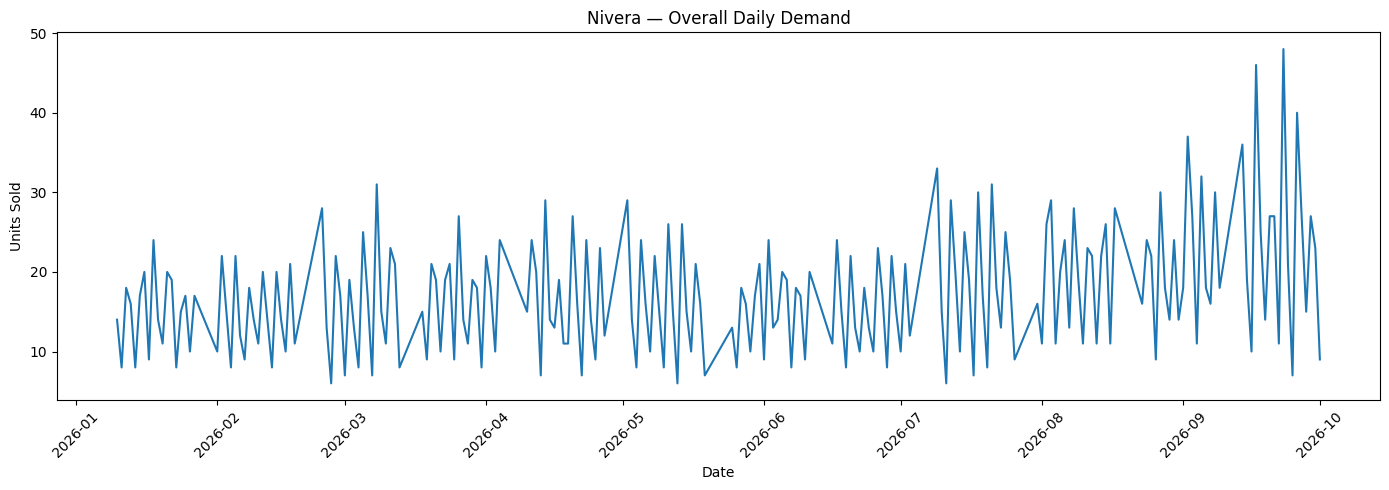

In [9]:
daily_total = (
    daily_demand
    .groupby("date", as_index=False)["demand"]
    .sum()
)

plt.figure(figsize=(14, 5))

plt.plot(
    daily_total["date"],
    daily_total["demand"]
)

plt.title("Nivera — Overall Daily Demand")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
# Step 10 — Aggregate product demand to weekly frequency

daily_demand["week"] = (
    daily_demand["date"]
    .dt.to_period("W")
    .dt.start_time
)

weekly_demand = (
    daily_demand
    .groupby(
        ["productId", "productName", "sku", "category", "week"],
        as_index=False
    )["demand"]
    .sum()
)

print("Weekly demand shape:", weekly_demand.shape)

print(
    "Number of products:",
    weekly_demand["productId"].nunique()
)

print(
    "Number of weeks:",
    weekly_demand["week"].nunique()
)

print(
    "Total units:",
    weekly_demand["demand"].sum()
)

display(weekly_demand.head(10))

Weekly demand shape: (1296, 6)
Number of products: 108
Number of weeks: 39
Total units: 3733


,productId,productName,sku,category,week,demand
0,6abd8e4ca19535d75c1ab843,Wireless Mechanical Keyboard,ELEC-KB-001,Electronics,2026-01-12,3
1,6abd8e4ca19535d75c1ab843,Wireless Mechanical Keyboard,ELEC-KB-001,Electronics,2026-02-02,2
2,6abd8e4ca19535d75c1ab843,Wireless Mechanical Keyboard,ELEC-KB-001,Electronics,2026-03-02,1
3,6abd8e4ca19535d75c1ab843,Wireless Mechanical Keyboard,ELEC-KB-001,Electronics,2026-03-23,3
4,6abd8e4ca19535d75c1ab843,Wireless Mechanical Keyboard,ELEC-KB-001,Electronics,2026-04-20,1
5,6abd8e4ca19535d75c1ab843,Wireless Mechanical Keyboard,ELEC-KB-001,Electronics,2026-05-18,1
6,6abd8e4ca19535d75c1ab843,Wireless Mechanical Keyboard,ELEC-KB-001,Electronics,2026-05-25,2
7,6abd8e4ca19535d75c1ab843,Wireless Mechanical Keyboard,ELEC-KB-001,Electronics,2026-06-15,2
8,6abd8e4ca19535d75c1ab843,Wireless Mechanical Keyboard,ELEC-KB-001,Electronics,2026-07-13,1
9,6abd8e4ca19535d75c1ab843,Wireless Mechanical Keyboard,ELEC-KB-001,Electronics,2026-08-10,4


In [11]:
print("Weekly demand statistics:")
print(weekly_demand["demand"].describe())

print("\nWeekly date range:")
print("Start:", weekly_demand["week"].min())
print("End  :", weekly_demand["week"].max())

Weekly demand statistics:
count    1296.000000
mean        2.880401
std         1.934539
min         1.000000
25%         2.000000
50%         2.000000
75%         4.000000
max        15.000000
Name: demand, dtype: float64

Weekly date range:
Start: 2026-01-05 00:00:00
End  : 2026-09-28 00:00:00


In [12]:
# Step 12 — Create complete weekly time series

all_products = weekly_demand[
    ["productId", "productName", "sku", "category"]
].drop_duplicates()

all_weeks = pd.DataFrame({
    "week": pd.date_range(
        weekly_demand["week"].min(),
        weekly_demand["week"].max(),
        freq="W-MON"
    )
})

all_products["key"] = 1
all_weeks["key"] = 1

complete_series = all_products.merge(
    all_weeks,
    on="key"
).drop(columns="key")

complete_series = complete_series.merge(
    weekly_demand,
    on=[
        "productId",
        "productName",
        "sku",
        "category",
        "week"
    ],
    how="left"
)

complete_series["demand"] = (
    complete_series["demand"]
    .fillna(0)
)

complete_series = complete_series.sort_values(
    ["productId", "week"]
).reset_index(drop=True)

print("Complete time-series shape:", complete_series.shape)

print(
    "Products:",
    complete_series["productId"].nunique()
)

print(
    "Weeks:",
    complete_series["week"].nunique()
)

print(
    "Total demand:",
    complete_series["demand"].sum()
)

display(complete_series.head(15))

Complete time-series shape: (4212, 6)
Products: 108
Weeks: 39
Total demand: 3733.0


,productId,productName,sku,category,week,demand
0,6abd8e4ca19535d75c1ab843,Wireless Mechanical Keyboard,ELEC-KB-001,Electronics,2026-01-05,0.0
1,6abd8e4ca19535d75c1ab843,Wireless Mechanical Keyboard,ELEC-KB-001,Electronics,2026-01-12,3.0
2,6abd8e4ca19535d75c1ab843,Wireless Mechanical Keyboard,ELEC-KB-001,Electronics,2026-01-19,0.0
3,6abd8e4ca19535d75c1ab843,Wireless Mechanical Keyboard,ELEC-KB-001,Electronics,2026-01-26,0.0
4,6abd8e4ca19535d75c1ab843,Wireless Mechanical Keyboard,ELEC-KB-001,Electronics,2026-02-02,2.0
5,6abd8e4ca19535d75c1ab843,Wireless Mechanical Keyboard,ELEC-KB-001,Electronics,2026-02-09,0.0
6,6abd8e4ca19535d75c1ab843,Wireless Mechanical Keyboard,ELEC-KB-001,Electronics,2026-02-16,0.0
7,6abd8e4ca19535d75c1ab843,Wireless Mechanical Keyboard,ELEC-KB-001,Electronics,2026-02-23,0.0
8,6abd8e4ca19535d75c1ab843,Wireless Mechanical Keyboard,ELEC-KB-001,Electronics,2026-03-02,1.0
9,6abd8e4ca19535d75c1ab843,Wireless Mechanical Keyboard,ELEC-KB-001,Electronics,2026-03-09,0.0


In [13]:
product_summary = (
    complete_series
    .groupby(
        ["productId", "productName", "category"],
        as_index=False
    )
    .agg(
        total_demand=("demand", "sum"),
        average_weekly_demand=("demand", "mean"),
        max_weekly_demand=("demand", "max"),
        demand_std=("demand", "std"),
        active_weeks=("demand", lambda x: (x > 0).sum())
    )
)

product_summary["demand_cv"] = (
    product_summary["demand_std"] /
    product_summary["average_weekly_demand"].replace(0, np.nan)
)

product_summary = product_summary.sort_values(
    "total_demand",
    ascending=False
)

display(product_summary.head(15))

,productId,productName,category,total_demand,average_weekly_demand,max_weekly_demand,demand_std,active_weeks,demand_cv
74,6abd8e4ca19535d75c1ab88d,Signature Eau de Parfum,Beauty & Personal Care,68.0,1.743590,15.0,3.282473,12,1.882595
32,6abd8e4ca19535d75c1ab863,Memory Foam Pillow,Home & Kitchen,67.0,1.717949,15.0,3.235890,12,1.883578
65,6abd8e4ca19535d75c1ab884,Data Science Fundamentals,Books,67.0,1.717949,12.0,3.008311,12,1.751106
16,6abd8e4ca19535d75c1ab853,Women's Running Shoes,Apparel,67.0,1.717949,13.0,3.051736,12,1.776383
3,6abd8e4ca19535d75c1ab846,Portable Bluetooth Speaker,Electronics,66.0,1.692308,11.0,2.948272,12,1.742161
50,6abd8e4ca19535d75c1ab875,Cricket Bat,Sports & Fitness,66.0,1.692308,11.0,3.027539,12,1.789000
5,6abd8e4ca19535d75c1ab848,Wireless Gaming Mouse,Electronics,66.0,1.692308,10.0,2.894222,12,1.710222
20,6abd8e4ca19535d75c1ab857,Men's Slim Fit Jeans,Apparel,65.0,1.666667,14.0,3.055050,12,1.833030
49,6abd8e4ca19535d75c1ab874,Football (Size 5),Sports & Fitness,65.0,1.666667,11.0,2.877621,12,1.726573
34,6abd8e4ca19535d75c1ab865,Dinner Set (16-Piece),Home & Kitchen,65.0,1.666667,10.0,2.859272,12,1.715563


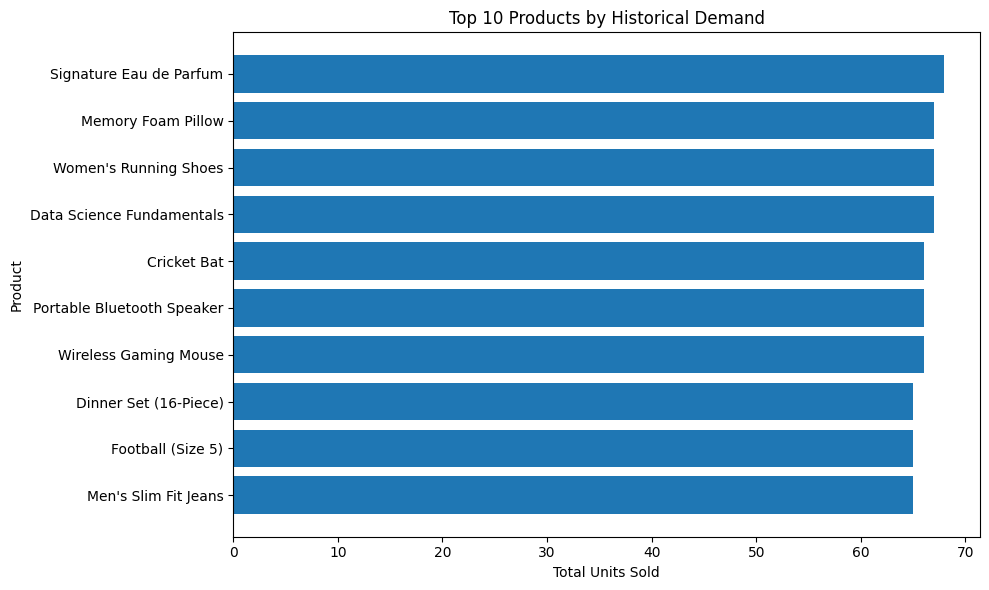

In [14]:
top_products = (
    product_summary
    .head(10)
    .sort_values("total_demand")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_products["productName"],
    top_products["total_demand"]
)

plt.title("Top 10 Products by Historical Demand")
plt.xlabel("Total Units Sold")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [15]:
# Step 15 — Time-based train/test split

TEST_WEEKS = 6

all_weeks_sorted = sorted(
    complete_series["week"].unique()
)

split_date = all_weeks_sorted[-TEST_WEEKS]

train_data = complete_series[
    complete_series["week"] < split_date
].copy()

test_data = complete_series[
    complete_series["week"] >= split_date
].copy()

print("Total weeks:", len(all_weeks_sorted))
print("Training weeks:", train_data["week"].nunique())
print("Testing weeks:", test_data["week"].nunique())

print("\nTraining period:")
print(train_data["week"].min(), "→", train_data["week"].max())

print("\nTesting period:")
print(test_data["week"].min(), "→", test_data["week"].max())

print("\nTraining rows:", len(train_data))
print("Testing rows:", len(test_data))

Total weeks: 39
Training weeks: 33
Testing weeks: 6

Training period:
2026-01-05 00:00:00 → 2026-08-17 00:00:00

Testing period:
2026-08-24 00:00:00 → 2026-09-28 00:00:00

Training rows: 3564
Testing rows: 648


In [16]:
# Step 16 — Create lag and rolling-demand features

model_data = complete_series.copy()

model_data = model_data.sort_values(
    ["productId", "week"]
).reset_index(drop=True)

grouped = model_data.groupby("productId")["demand"]

model_data["lag_1"] = grouped.shift(1)
model_data["lag_2"] = grouped.shift(2)
model_data["lag_3"] = grouped.shift(3)
model_data["lag_4"] = grouped.shift(4)

model_data["rolling_mean_3"] = (
    grouped.shift(1)
    .rolling(3)
    .mean()
    .reset_index(level=0, drop=True)
)

model_data["rolling_mean_4"] = (
    grouped.shift(1)
    .rolling(4)
    .mean()
    .reset_index(level=0, drop=True)
)

model_data["rolling_mean_8"] = (
    grouped.shift(1)
    .rolling(8)
    .mean()
    .reset_index(level=0, drop=True)
)

model_data["rolling_std_4"] = (
    grouped.shift(1)
    .rolling(4)
    .std()
    .reset_index(level=0, drop=True)
)

print("Feature dataset shape:", model_data.shape)

display(model_data.head(15))

Feature dataset shape: (4212, 14)


,productId,productName,sku,category,week,demand,lag_1,lag_2,lag_3,lag_4,rolling_mean_3,rolling_mean_4,rolling_mean_8,rolling_std_4
0,6abd8e4ca19535d75c1ab843,Wireless Mechanical Keyboard,ELEC-KB-001,Electronics,2026-01-05,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6abd8e4ca19535d75c1ab843,Wireless Mechanical Keyboard,ELEC-KB-001,Electronics,2026-01-12,3.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,6abd8e4ca19535d75c1ab843,Wireless Mechanical Keyboard,ELEC-KB-001,Electronics,2026-01-19,0.0,3.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,6abd8e4ca19535d75c1ab843,Wireless Mechanical Keyboard,ELEC-KB-001,Electronics,2026-01-26,0.0,0.0,3.0,0.0,NaN,1.000000,NaN,NaN,NaN
4,6abd8e4ca19535d75c1ab843,Wireless Mechanical Keyboard,ELEC-KB-001,Electronics,2026-02-02,2.0,0.0,0.0,3.0,0.0,1.000000,0.75,NaN,1.500000
5,6abd8e4ca19535d75c1ab843,Wireless Mechanical Keyboard,ELEC-KB-001,Electronics,2026-02-09,0.0,2.0,0.0,0.0,3.0,0.666667,1.25,NaN,1.500000
6,6abd8e4ca19535d75c1ab843,Wireless Mechanical Keyboard,ELEC-KB-001,Electronics,2026-02-16,0.0,0.0,2.0,0.0,0.0,0.666667,0.50,NaN,1.000000
7,6abd8e4ca19535d75c1ab843,Wireless Mechanical Keyboard,ELEC-KB-001,Electronics,2026-02-23,0.0,0.0,0.0,2.0,0.0,0.666667,0.50,NaN,1.000000
8,6abd8e4ca19535d75c1ab843,Wireless Mechanical Keyboard,ELEC-KB-001,Electronics,2026-03-02,1.0,0.0,0.0,0.0,2.0,0.000000,0.50,0.625,1.000000
9,6abd8e4ca19535d75c1ab843,Wireless Mechanical Keyboard,ELEC-KB-001,Electronics,2026-03-09,0.0,1.0,0.0,0.0,0.0,0.333333,0.25,0.750,0.500000


In [17]:
# Step 17 — Add time-based features

model_data["week_number"] = (
    model_data["week"].dt.isocalendar().week.astype(int)
)

model_data["month"] = (
    model_data["week"].dt.month
)

model_data["quarter"] = (
    model_data["week"].dt.quarter
)

# Sequential time index
model_data["time_index"] = (
    model_data.groupby("productId").cumcount()
)

display(
    model_data[
        [
            "productName",
            "week",
            "demand",
            "lag_1",
            "lag_2",
            "lag_3",
            "rolling_mean_3",
            "rolling_mean_8",
            "week_number"
        ]
    ].head(15)
)

,productName,week,demand,lag_1,lag_2,lag_3,rolling_mean_3,rolling_mean_8,week_number
0,Wireless Mechanical Keyboard,2026-01-05,0.0,NaN,NaN,NaN,NaN,NaN,2
1,Wireless Mechanical Keyboard,2026-01-12,3.0,0.0,NaN,NaN,NaN,NaN,3
2,Wireless Mechanical Keyboard,2026-01-19,0.0,3.0,0.0,NaN,NaN,NaN,4
3,Wireless Mechanical Keyboard,2026-01-26,0.0,0.0,3.0,0.0,1.000000,NaN,5
4,Wireless Mechanical Keyboard,2026-02-02,2.0,0.0,0.0,3.0,1.000000,NaN,6
5,Wireless Mechanical Keyboard,2026-02-09,0.0,2.0,0.0,0.0,0.666667,NaN,7
6,Wireless Mechanical Keyboard,2026-02-16,0.0,0.0,2.0,0.0,0.666667,NaN,8
7,Wireless Mechanical Keyboard,2026-02-23,0.0,0.0,0.0,2.0,0.666667,NaN,9
8,Wireless Mechanical Keyboard,2026-03-02,1.0,0.0,0.0,0.0,0.000000,0.625,10
9,Wireless Mechanical Keyboard,2026-03-09,0.0,1.0,0.0,0.0,0.333333,0.750,11


In [18]:
# Step 18 — Remove rows with insufficient historical information

feature_columns = [
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_4",
    "rolling_mean_3",
    "rolling_mean_4",
    "rolling_mean_8",
    "rolling_std_4",
    "week_number",
    "month",
    "quarter",
    "time_index"
]

model_data = model_data.dropna(
    subset=feature_columns
).copy()

print("Model dataset shape:", model_data.shape)
print("Missing feature values:")
print(model_data[feature_columns].isna().sum().sum())

Model dataset shape: (3348, 18)
Missing feature values:
0


In [19]:
# Step 19 — Prepare features and target

FEATURES = [
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_4",
    "rolling_mean_3",
    "rolling_mean_4",
    "rolling_mean_8",
    "rolling_std_4",
    "week_number",
    "month",
    "quarter",
    "time_index"
]

TARGET = "demand"

X = model_data[FEATURES].copy()
y = model_data[TARGET].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(FEATURES)

X shape: (3348, 12)
y shape: (3348,)

Features:
['lag_1', 'lag_2', 'lag_3', 'lag_4', 'rolling_mean_3', 'rolling_mean_4', 'rolling_mean_8', 'rolling_std_4', 'week_number', 'month', 'quarter', 'time_index']


In [20]:
# Step 20 — Create final train/test datasets

X_train = model_data[
    model_data["week"] < split_date
][FEATURES]

y_train = model_data[
    model_data["week"] < split_date
][TARGET]

X_test = model_data[
    model_data["week"] >= split_date
][FEATURES]

y_test = model_data[
    model_data["week"] >= split_date
][TARGET]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

print("\nTrain period:")
print(
    model_data.loc[
        model_data["week"] < split_date,
        "week"
    ].min(),
    "→",
    model_data.loc[
        model_data["week"] < split_date,
        "week"
    ].max()
)

print("\nTest period:")
print(
    model_data.loc[
        model_data["week"] >= split_date,
        "week"
    ].min(),
    "→",
    model_data.loc[
        model_data["week"] >= split_date,
        "week"
    ].max()
)

X_train: (2700, 12)
y_train: (2700,)
X_test : (648, 12)
y_test : (648,)

Train period:
2026-03-02 00:00:00 → 2026-08-17 00:00:00

Test period:
2026-08-24 00:00:00 → 2026-09-28 00:00:00


In [21]:
# Step 21 — Naive forecast

naive_test = model_data[
    model_data["week"] >= split_date
].copy()

naive_test["prediction_naive"] = naive_test["lag_1"]

print(
    naive_test[
        [
            "productName",
            "week",
            "demand",
            "prediction_naive"
        ]
    ].head(15)
)

                      productName       week  demand  prediction_naive
33   Wireless Mechanical Keyboard 2026-08-24     0.0               0.0
34   Wireless Mechanical Keyboard 2026-08-31     3.0               0.0
35   Wireless Mechanical Keyboard 2026-09-07     0.0               3.0
36   Wireless Mechanical Keyboard 2026-09-14     0.0               0.0
37   Wireless Mechanical Keyboard 2026-09-21     0.0               0.0
38   Wireless Mechanical Keyboard 2026-09-28     1.0               0.0
72    Noise Cancelling Headphones 2026-08-24     5.0               0.0
73    Noise Cancelling Headphones 2026-08-31     0.0               5.0
74    Noise Cancelling Headphones 2026-09-07     0.0               0.0
75    Noise Cancelling Headphones 2026-09-14     0.0               0.0
76    Noise Cancelling Headphones 2026-09-21     5.0               0.0
77    Noise Cancelling Headphones 2026-09-28     0.0               5.0
111      USB-C Fast Charger (65W) 2026-08-24     0.0               4.0
112   

In [22]:
# Step 22 — Evaluation function

def evaluate_forecast(actual, predicted):
    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    return {
        "MAE": mae,
        "RMSE": rmse
    }


naive_metrics = evaluate_forecast(
    naive_test["demand"],
    naive_test["prediction_naive"]
)

print("Naive Forecast Results")
print("----------------------")
print(f"MAE : {naive_metrics['MAE']:.4f}")
print(f"RMSE: {naive_metrics['RMSE']:.4f}")

Naive Forecast Results
----------------------
MAE : 2.2037
RMSE: 3.5888


In [23]:
# Step 23 — 4-week moving average forecast

moving_test = model_data[
    model_data["week"] >= split_date
].copy()

moving_test["prediction_ma4"] = (
    moving_test["rolling_mean_4"]
)

moving_metrics = evaluate_forecast(
    moving_test["demand"],
    moving_test["prediction_ma4"]
)

print("4-Week Moving Average Results")
print("------------------------------")
print(f"MAE : {moving_metrics['MAE']:.4f}")
print(f"RMSE: {moving_metrics['RMSE']:.4f}")

4-Week Moving Average Results
------------------------------
MAE : 1.7485
RMSE: 2.5393


In [24]:
baseline_results = pd.DataFrame([
    {
        "Model": "Naive",
        "MAE": naive_metrics["MAE"],
        "RMSE": naive_metrics["RMSE"]
    },
    {
        "Model": "Moving Average (4 weeks)",
        "MAE": moving_metrics["MAE"],
        "RMSE": moving_metrics["RMSE"]
    }
])

display(
    baseline_results.sort_values("MAE")
)

,Model,MAE,RMSE
1,Moving Average (4 weeks),1.748457,2.539313
0,Naive,2.203704,3.588820


In [25]:
# Step 25 — Linear Regression

from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_model.fit(
    X_train,
    y_train
)

linear_predictions = linear_model.predict(X_test)

# Demand cannot be negative
linear_predictions = np.maximum(
    linear_predictions,
    0
)

linear_metrics = evaluate_forecast(
    y_test,
    linear_predictions
)

print("Linear Regression Results")
print("-------------------------")
print(f"MAE : {linear_metrics['MAE']:.4f}")
print(f"RMSE: {linear_metrics['RMSE']:.4f}")

Linear Regression Results
-------------------------
MAE : 1.1693
RMSE: 2.0026


In [26]:
# Step 26 — Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

rf_predictions = rf_model.predict(X_test)

rf_predictions = np.maximum(
    rf_predictions,
    0
)

rf_metrics = evaluate_forecast(
    y_test,
    rf_predictions
)

print("Random Forest Results")
print("---------------------")
print(f"MAE : {rf_metrics['MAE']:.4f}")
print(f"RMSE: {rf_metrics['RMSE']:.4f}")

Random Forest Results
---------------------
MAE : 1.0124
RMSE: 1.8334


In [27]:
# Step 27 — Gradient Boosting Regressor

from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    min_samples_leaf=3,
    random_state=42
)

gb_model.fit(
    X_train,
    y_train
)

gb_predictions = gb_model.predict(X_test)

gb_predictions = np.maximum(
    gb_predictions,
    0
)

gb_metrics = evaluate_forecast(
    y_test,
    gb_predictions
)

print("Gradient Boosting Results")
print("-------------------------")
print(f"MAE : {gb_metrics['MAE']:.4f}")
print(f"RMSE: {gb_metrics['RMSE']:.4f}")

Gradient Boosting Results
-------------------------
MAE : 1.0444
RMSE: 1.8973


In [28]:
# Step 27 — Gradient Boosting Regressor

from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    min_samples_leaf=3,
    random_state=42
)

gb_model.fit(
    X_train,
    y_train
)

gb_predictions = gb_model.predict(X_test)

gb_predictions = np.maximum(
    gb_predictions,
    0
)

gb_metrics = evaluate_forecast(
    y_test,
    gb_predictions
)

print("Gradient Boosting Results")
print("-------------------------")
print(f"MAE : {gb_metrics['MAE']:.4f}")
print(f"RMSE: {gb_metrics['RMSE']:.4f}")

Gradient Boosting Results
-------------------------
MAE : 1.0444
RMSE: 1.8973


In [29]:
# Step 28 — Compare all forecasting models

forecast_results = pd.DataFrame([
    {
        "Model": "Naive",
        "MAE": naive_metrics["MAE"],
        "RMSE": naive_metrics["RMSE"]
    },
    {
        "Model": "Moving Average (4 weeks)",
        "MAE": moving_metrics["MAE"],
        "RMSE": moving_metrics["RMSE"]
    },
    {
        "Model": "Linear Regression",
        "MAE": linear_metrics["MAE"],
        "RMSE": linear_metrics["RMSE"]
    },
    {
        "Model": "Random Forest",
        "MAE": rf_metrics["MAE"],
        "RMSE": rf_metrics["RMSE"]
    },
    {
        "Model": "Gradient Boosting",
        "MAE": gb_metrics["MAE"],
        "RMSE": gb_metrics["RMSE"]
    }
])

forecast_results = forecast_results.sort_values(
    "MAE"
).reset_index(drop=True)

display(forecast_results)

,Model,MAE,RMSE
0,Random Forest,1.012417,1.833413
1,Gradient Boosting,1.044378,1.897263
2,Linear Regression,1.169272,2.002618
3,Moving Average (4 weeks),1.748457,2.539313
4,Naive,2.203704,3.588820


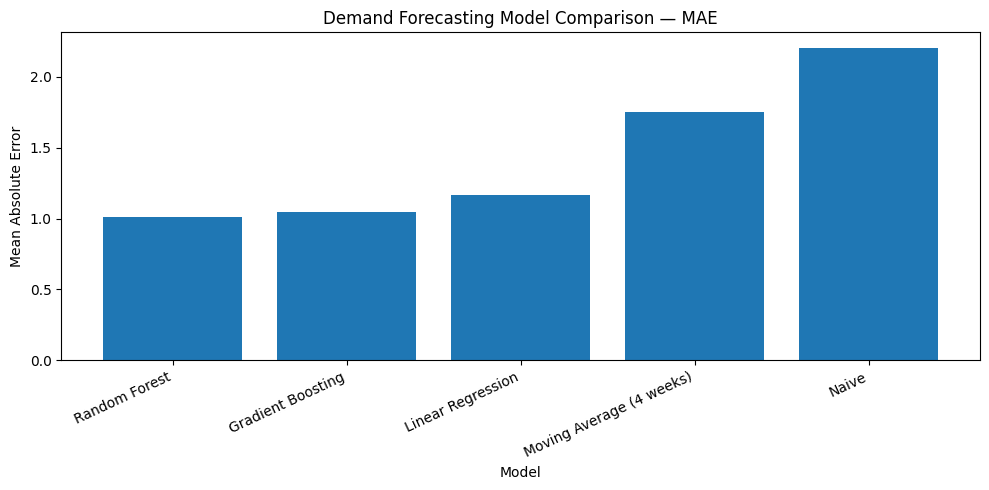

In [30]:
# Step 29 — Compare MAE

plt.figure(figsize=(10, 5))

plt.bar(
    forecast_results["Model"],
    forecast_results["MAE"]
)

plt.title("Demand Forecasting Model Comparison — MAE")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error")

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()
plt.show()

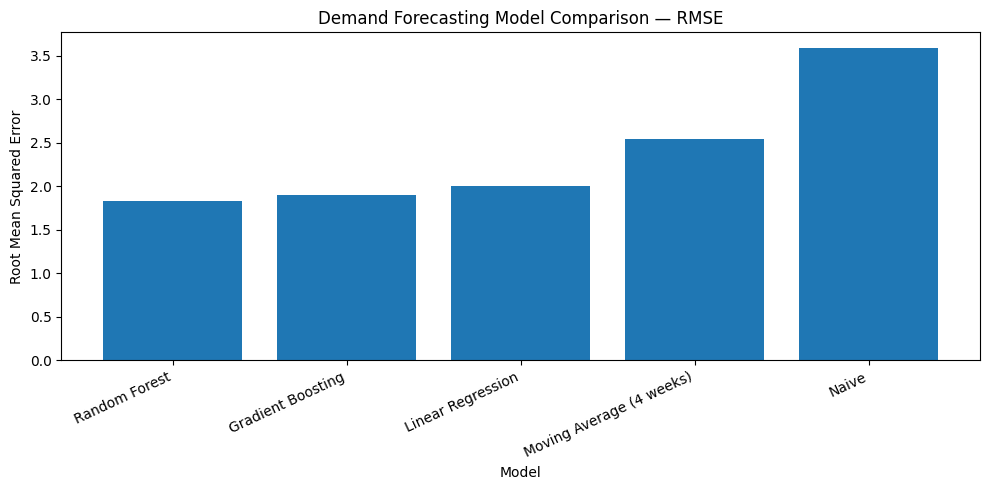

In [31]:
# Step 30 — Compare RMSE

plt.figure(figsize=(10, 5))

plt.bar(
    forecast_results["Model"],
    forecast_results["RMSE"]
)

plt.title("Demand Forecasting Model Comparison — RMSE")
plt.xlabel("Model")
plt.ylabel("Root Mean Squared Error")

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()
plt.show()

In [32]:
# Step 31 — Product-level Random Forest evaluation

test_predictions = model_data[
    model_data["week"] >= split_date
].copy()

test_predictions["rf_prediction"] = rf_predictions

product_metrics = (
    test_predictions
    .groupby(
        ["productId", "productName", "category"]
    )
    .apply(
        lambda g: pd.Series({
            "MAE": mean_absolute_error(
                g["demand"],
                g["rf_prediction"]
            ),
            "RMSE": np.sqrt(
                mean_squared_error(
                    g["demand"],
                    g["rf_prediction"]
                )
            ),
            "actual_demand": g["demand"].sum(),
            "forecast_demand": g["rf_prediction"].sum()
        }),
        include_groups=False
    )
    .reset_index()
)

print("Products evaluated:", len(product_metrics))

display(
    product_metrics
    .sort_values("MAE")
    .head(10)
)

Products evaluated: 108


,productId,productName,category,MAE,RMSE,actual_demand,forecast_demand
56,6abd8e4ca19535d75c1ab87b,Table Tennis Paddle Set,Sports & Fitness,0.133685,0.263067,3.0,3.802111
6,6abd8e4ca19535d75c1ab849,1080p USB Webcam,Electronics,0.253668,0.314378,3.0,4.522006
104,6abd8e4ca19535d75c1ab8ab,Mini Building Blocks,Toys & Games,0.261079,0.515768,5.0,6.482131
78,6abd8e4ca19535d75c1ab891,Beard Grooming Oil,Beauty & Personal Care,0.302070,0.517244,3.0,4.217716
90,6abd8e4ca19535d75c1ab89d,Green Tea Bags,Groceries,0.303075,0.457390,4.0,4.930790
2,6abd8e4ca19535d75c1ab845,USB-C Fast Charger (65W),Electronics,0.333491,0.519711,5.0,7.000943
92,6abd8e4ca19535d75c1ab89f,Dark Chocolate Bar,Groceries,0.359424,0.615904,3.0,5.156545
96,6abd8e4ca19535d75c1ab8a3,Wooden Building Blocks Set,Toys & Games,0.371949,0.598847,4.0,5.090788
24,6abd8e4ca19535d75c1ab85b,Unisex Track Pants,Apparel,0.373594,0.487807,4.0,4.077016
42,6abd8e4ca19535d75c1ab86d,Ceramic Coffee Mug Set,Home & Kitchen,0.376681,0.554047,3.0,5.260085


In [33]:
# Step 32 — Worst-performing products

print("Worst 10 products by MAE:")

display(
    product_metrics
    .sort_values("MAE", ascending=False)
    .head(10)
)

Worst 10 products by MAE:


,productId,productName,category,MAE,RMSE,actual_demand,forecast_demand
16,6abd8e4ca19535d75c1ab853,Women's Running Shoes,Apparel,3.105729,4.183756,21.0,11.785037
97,6abd8e4ca19535d75c1ab8a4,Strategy Board Game,Toys & Games,2.645607,3.890599,16.0,5.700430
32,6abd8e4ca19535d75c1ab863,Memory Foam Pillow,Home & Kitchen,2.638296,4.248249,18.0,11.463889
86,6abd8e4ca19535d75c1ab899,Multigrain Breakfast Cereal,Groceries,2.357229,3.183440,16.0,11.941963
65,6abd8e4ca19535d75c1ab884,Data Science Fundamentals,Books,2.340409,3.792491,18.0,13.201451
34,6abd8e4ca19535d75c1ab865,Dinner Set (16-Piece),Home & Kitchen,2.226014,3.314278,18.0,11.817725
74,6abd8e4ca19535d75c1ab88d,Signature Eau de Parfum,Beauty & Personal Care,2.224059,4.273688,15.0,7.891041
49,6abd8e4ca19535d75c1ab874,Football (Size 5),Sports & Fitness,2.218611,3.880899,17.0,11.244959
5,6abd8e4ca19535d75c1ab848,Wireless Gaming Mouse,Electronics,2.198265,4.113857,16.0,8.382712
47,6abd8e4ca19535d75c1ab872,Insulated Water Bottle (1L),Sports & Fitness,2.130609,3.167183,16.0,13.462894


In [34]:
# Step 33 — Distribution of product-level errors

print("Product-level MAE statistics:")
print(product_metrics["MAE"].describe())

print("\nProduct-level RMSE statistics:")
print(product_metrics["RMSE"].describe())

print(
    "\nProducts with MAE <= 1:",
    (product_metrics["MAE"] <= 1).sum()
)

print(
    "Products with MAE <= 1.5:",
    (product_metrics["MAE"] <= 1.5).sum()
)

print(
    "Products with MAE > 2:",
    (product_metrics["MAE"] > 2).sum()
)

Product-level MAE statistics:
count    108.000000
mean       1.012417
std        0.609260
min        0.133685
25%        0.589295
50%        0.823030
75%        1.257830
max        3.105729
Name: MAE, dtype: float64

Product-level RMSE statistics:
count    108.000000
mean       1.560584
std        0.966766
min        0.263067
25%        0.859880
50%        1.332344
75%        1.833204
max        4.273688
Name: RMSE, dtype: float64

Products with MAE <= 1: 65
Products with MAE <= 1.5: 89
Products with MAE > 2: 12


In [35]:
# Step 34 — Random Forest feature importance

feature_importance = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
4,rolling_mean_3,0.403544
6,rolling_mean_8,0.176449
8,week_number,0.085134
11,time_index,0.084368
1,lag_2,0.050495
5,rolling_mean_4,0.041029
3,lag_4,0.040765
7,rolling_std_4,0.039595
9,month,0.026382
0,lag_1,0.025528


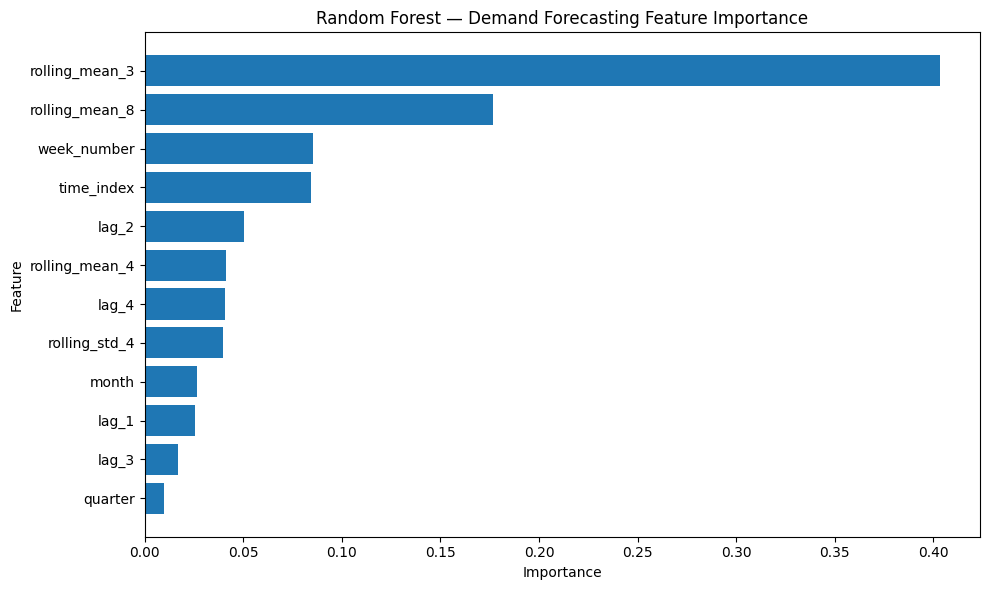

In [36]:
# Step 34B — Feature importance visualization

importance_plot = feature_importance.sort_values(
    "Importance"
)

plt.figure(figsize=(10, 6))

plt.barh(
    importance_plot["Feature"],
    importance_plot["Importance"]
)

plt.title("Random Forest — Demand Forecasting Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [37]:
# Step 35 — Train final Random Forest on all available historical data

final_rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

X_all = model_data[FEATURES]
y_all = model_data[TARGET]

final_rf_model.fit(
    X_all,
    y_all
)

print("Final Random Forest trained.")
print("Training rows:", len(X_all))
print("Features:", len(FEATURES))

Final Random Forest trained.
Training rows: 3348
Features: 12


In [38]:
# Step 36 — Create next-week forecasting features

latest_data = (
    model_data
    .sort_values(["productId", "week"])
    .groupby("productId")
    .tail(1)
    .copy()
)

print("Products available for forecasting:",
      latest_data["productId"].nunique())

display(
    latest_data[
        [
            "productName",
            "week",
            "demand",
            "lag_1",
            "lag_2",
            "lag_3",
            "lag_4",
            "rolling_mean_3",
            "rolling_mean_4",
            "rolling_mean_8"
        ]
    ].head(10)
)

Products available for forecasting: 108


,productName,week,demand,lag_1,lag_2,lag_3,lag_4,rolling_mean_3,rolling_mean_4,rolling_mean_8
38,Wireless Mechanical Keyboard,2026-09-28,1.0,0.0,0.0,0.0,3.0,0.000000,0.75,0.875
77,Noise Cancelling Headphones,2026-09-28,0.0,5.0,0.0,0.0,0.0,1.666667,1.25,1.750
116,USB-C Fast Charger (65W),2026-09-28,0.0,0.0,5.0,0.0,0.0,1.666667,1.25,1.625
155,Portable Bluetooth Speaker,2026-09-28,6.0,0.0,0.0,0.0,11.0,0.000000,2.75,2.375
194,Fitness Smart Watch,2026-09-28,0.0,11.0,0.0,0.0,0.0,3.666667,2.75,2.375
233,Wireless Gaming Mouse,2026-09-28,0.0,0.0,10.0,6.0,0.0,5.333333,4.00,2.625
272,1080p USB Webcam,2026-09-28,0.0,1.0,0.0,0.0,2.0,0.333333,0.75,0.750
311,Bluetooth Neckband,2026-09-28,0.0,0.0,2.0,0.0,0.0,0.666667,0.50,0.750
350,Portable SSD 1TB,2026-09-28,3.0,0.0,0.0,0.0,1.0,0.000000,0.25,0.500
389,USB-C Hub 7-in-1,2026-09-28,0.0,1.0,0.0,0.0,0.0,0.333333,0.25,0.500


In [39]:
# Step 37 — Generate next-week demand forecast

latest_week = model_data["week"].max()

next_week = (
    latest_week + pd.Timedelta(days=7)
)

next_week_features = latest_data[
    FEATURES
].copy()

next_week_predictions = final_rf_model.predict(
    next_week_features
)

next_week_predictions = np.maximum(
    next_week_predictions,
    0
)

forecast_next_week = latest_data[
    [
        "productId",
        "productName",
        "sku",
        "category"
    ]
].copy()

forecast_next_week["forecast_week"] = next_week

forecast_next_week["forecast_demand"] = (
    next_week_predictions
)

forecast_next_week["forecast_demand"] = (
    forecast_next_week["forecast_demand"]
    .round(2)
)

forecast_next_week = forecast_next_week.sort_values(
    "forecast_demand",
    ascending=False
).reset_index(drop=True)

print("Forecast week:", next_week)
print(
    "Products forecasted:",
    len(forecast_next_week)
)

display(
    forecast_next_week.head(20)
)

Forecast week: 2026-10-05 00:00:00
Products forecasted: 108


,productId,productName,sku,category,forecast_week,forecast_demand
0,6abd8e4ca19535d75c1ab8a5,Remote Control Car,TOY-RC-003,Toys & Games,2026-10-05,8.18
1,6abd8e4ca19535d75c1ab846,Portable Bluetooth Speaker,ELEC-SPK-004,Electronics,2026-10-05,7.17
2,6abd8e4ca19535d75c1ab88e,Vitamin C Serum,BEAU-SR-004,Beauty & Personal Care,2026-10-05,6.73
3,6abd8e4ca19535d75c1ab874,Football (Size 5),SPRT-FB-005,Sports & Fitness,2026-10-05,6.09
4,6abd8e4ca19535d75c1ab862,Electric Kettle (1.5L),HOME-KT-002,Home & Kitchen,2026-10-05,5.06
5,6abd8e4ca19535d75c1ab855,Cotton Hoodie,APP-HD-004,Apparel,2026-10-05,4.67
6,6abd8e4ca19535d75c1ab893,Hair Styling Wax,BEAU-HW-009,Beauty & Personal Care,2026-10-05,3.71
7,6abd8e4ca19535d75c1ab881,Atomic Focus,BOOK-SH-003,Books,2026-10-05,3.38
8,6abd8e4ca19535d75c1ab85d,Men's Formal Trousers,APP-FT-012,Apparel,2026-10-05,3.38
9,6abd8e4ca19535d75c1ab84b,Portable SSD 1TB,ELEC-SSD-009,Electronics,2026-10-05,3.24


In [40]:
# Step 38 — Operational demand forecast

forecast_next_week["forecast_units"] = np.ceil(
    forecast_next_week["forecast_demand"]
).astype(int)

forecast_next_week["forecast_units"] = (
    forecast_next_week["forecast_units"].clip(lower=0)
)

print("Total forecasted units:",
      forecast_next_week["forecast_units"].sum())

display(
    forecast_next_week.head(20)
)

Total forecasted units: 143


,productId,productName,sku,category,forecast_week,forecast_demand,forecast_units
0,6abd8e4ca19535d75c1ab8a5,Remote Control Car,TOY-RC-003,Toys & Games,2026-10-05,8.18,9
1,6abd8e4ca19535d75c1ab846,Portable Bluetooth Speaker,ELEC-SPK-004,Electronics,2026-10-05,7.17,8
2,6abd8e4ca19535d75c1ab88e,Vitamin C Serum,BEAU-SR-004,Beauty & Personal Care,2026-10-05,6.73,7
3,6abd8e4ca19535d75c1ab874,Football (Size 5),SPRT-FB-005,Sports & Fitness,2026-10-05,6.09,7
4,6abd8e4ca19535d75c1ab862,Electric Kettle (1.5L),HOME-KT-002,Home & Kitchen,2026-10-05,5.06,6
5,6abd8e4ca19535d75c1ab855,Cotton Hoodie,APP-HD-004,Apparel,2026-10-05,4.67,5
6,6abd8e4ca19535d75c1ab893,Hair Styling Wax,BEAU-HW-009,Beauty & Personal Care,2026-10-05,3.71,4
7,6abd8e4ca19535d75c1ab881,Atomic Focus,BOOK-SH-003,Books,2026-10-05,3.38,4
8,6abd8e4ca19535d75c1ab85d,Men's Formal Trousers,APP-FT-012,Apparel,2026-10-05,3.38,4
9,6abd8e4ca19535d75c1ab84b,Portable SSD 1TB,ELEC-SSD-009,Electronics,2026-10-05,3.24,4


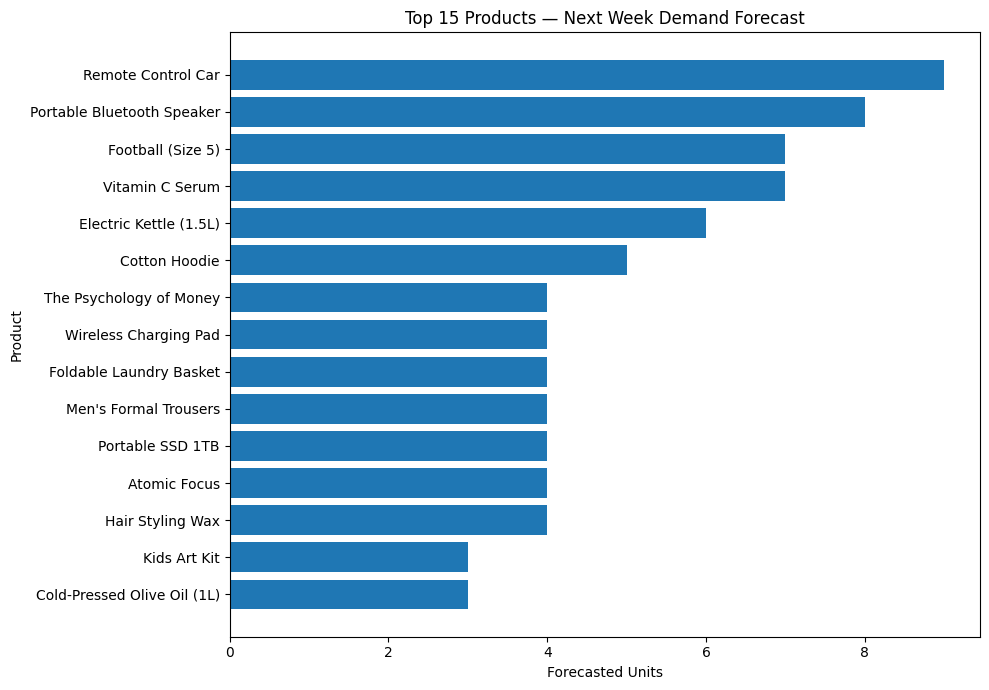

In [41]:
# Step 39 — Top 15 predicted-demand products

top_forecast = (
    forecast_next_week
    .head(15)
    .sort_values("forecast_units")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_forecast["productName"],
    top_forecast["forecast_units"]
)

plt.title("Top 15 Products — Next Week Demand Forecast")
plt.xlabel("Forecasted Units")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [42]:
# Step 40 — Save forecast output

OUTPUT_PATH = "../data/nivera_demand_forecast.csv"

forecast_next_week.to_csv(
    OUTPUT_PATH,
    index=False
)

print("Forecast saved to:")
print(OUTPUT_PATH)

print("\nRows saved:",
      len(forecast_next_week))

Forecast saved to:
../data/nivera_demand_forecast.csv

Rows saved: 108


In [43]:
# Step 41 — Recursive multi-week demand forecasting

def recursive_forecast(
    model,
    historical_data,
    weeks_ahead=39
):
    """
    Generate recursive weekly forecasts for every product.

    The prediction for each future week is fed back into
    the next week's lag and rolling-demand features.
    """

    products = (
        historical_data[
            [
                "productId",
                "productName",
                "sku",
                "category"
            ]
        ]
        .drop_duplicates("productId")
        .reset_index(drop=True)
    )

    # Complete historical demand for every product
    history = {}

    for product_id, group in historical_data.groupby("productId"):
        group = group.sort_values("week")

        history[product_id] = (
            group["demand"]
            .astype(float)
            .tolist()
        )

    last_week = historical_data["week"].max()

    future_records = []

    for step in range(1, weeks_ahead + 1):

        forecast_week = (
            last_week +
            pd.Timedelta(weeks=step)
        )

        rows = []

        for _, product in products.iterrows():

            product_id = product["productId"]

            values = history[product_id]

            # Latest historical/predicted demand
            lag_1 = values[-1]
            lag_2 = values[-2]
            lag_3 = values[-3]
            lag_4 = values[-4]

            rolling_mean_3 = np.mean(
                values[-3:]
            )

            rolling_mean_4 = np.mean(
                values[-4:]
            )

            rolling_mean_8 = np.mean(
                values[-8:]
            )

            rolling_std_4 = np.std(
                values[-4:],
                ddof=1
            )

            week_number = int(
                forecast_week.isocalendar().week
            )

            month = forecast_week.month

            quarter = forecast_week.quarter

            time_index = len(values)

            rows.append({
                "productId": product_id,
                "productName": product["productName"],
                "sku": product["sku"],
                "category": product["category"],
                "week": forecast_week,

                "lag_1": lag_1,
                "lag_2": lag_2,
                "lag_3": lag_3,
                "lag_4": lag_4,

                "rolling_mean_3": rolling_mean_3,
                "rolling_mean_4": rolling_mean_4,
                "rolling_mean_8": rolling_mean_8,
                "rolling_std_4": rolling_std_4,

                "week_number": week_number,
                "month": month,
                "quarter": quarter,
                "time_index": time_index
            })

        feature_frame = pd.DataFrame(rows)

        predictions = model.predict(
            feature_frame[FEATURES]
        )

        predictions = np.maximum(
            predictions,
            0
        )

        feature_frame["forecast_demand"] = predictions

        # Feed predictions back into history
        for i, row in feature_frame.iterrows():

            product_id = row["productId"]

            history[product_id].append(
                float(row["forecast_demand"])
            )

        future_records.append(
            feature_frame[
                [
                    "productId",
                    "productName",
                    "sku",
                    "category",
                    "week",
                    "forecast_demand"
                ]
            ]
        )

    return pd.concat(
        future_records,
        ignore_index=True
    )

In [44]:
# Step 42 — Generate 39 weeks of future demand

future_forecasts = recursive_forecast(
    model=final_rf_model,
    historical_data=complete_series,
    weeks_ahead=39
)

print(
    "Future forecast shape:",
    future_forecasts.shape
)

print(
    "Products:",
    future_forecasts["productId"].nunique()
)

print(
    "Future weeks:",
    future_forecasts["week"].nunique()
)

print(
    "Forecast period:"
)

print(
    future_forecasts["week"].min(),
    "→",
    future_forecasts["week"].max()
)

display(
    future_forecasts.head(15)
)

Future forecast shape: (4212, 6)
Products: 108
Future weeks: 39
Forecast period:
2026-10-05 00:00:00 → 2027-06-28 00:00:00


,productId,productName,sku,category,week,forecast_demand
0,6abd8e4ca19535d75c1ab843,Wireless Mechanical Keyboard,ELEC-KB-001,Electronics,2026-10-05,0.146122
1,6abd8e4ca19535d75c1ab844,Noise Cancelling Headphones,ELEC-HP-002,Electronics,2026-10-05,0.034000
2,6abd8e4ca19535d75c1ab845,USB-C Fast Charger (65W),ELEC-CH-003,Electronics,2026-10-05,1.813042
3,6abd8e4ca19535d75c1ab846,Portable Bluetooth Speaker,ELEC-SPK-004,Electronics,2026-10-05,0.326386
4,6abd8e4ca19535d75c1ab847,Fitness Smart Watch,ELEC-SW-005,Electronics,2026-10-05,0.000000
5,6abd8e4ca19535d75c1ab848,Wireless Gaming Mouse,ELEC-MS-006,Electronics,2026-10-05,3.191325
6,6abd8e4ca19535d75c1ab849,1080p USB Webcam,ELEC-WC-007,Electronics,2026-10-05,0.000000
7,6abd8e4ca19535d75c1ab84a,Bluetooth Neckband,ELEC-NB-008,Electronics,2026-10-05,0.505268
8,6abd8e4ca19535d75c1ab84b,Portable SSD 1TB,ELEC-SSD-009,Electronics,2026-10-05,0.421941
9,6abd8e4ca19535d75c1ab84c,USB-C Hub 7-in-1,ELEC-HUB-010,Electronics,2026-10-05,0.000000


In [45]:
# Step 43 — Calculate 3-, 6-, and 9-month demand forecasts

HORIZONS = {
    "forecast_3_month": 13,
    "forecast_6_month": 26,
    "forecast_9_month": 39
}

horizon_forecasts = (
    future_forecasts
    .groupby(
        ["productId", "productName", "sku", "category"]
    )
    .agg(
        forecast_3_month=(
            "forecast_demand",
            lambda x: x.iloc[:13].sum()
        ),
        forecast_6_month=(
            "forecast_demand",
            lambda x: x.iloc[:26].sum()
        ),
        forecast_9_month=(
            "forecast_demand",
            "sum"
        )
    )
    .reset_index()
)

print(
    "Products with multi-horizon forecasts:",
    len(horizon_forecasts)
)

display(
    horizon_forecasts.head(20)
)

Products with multi-horizon forecasts: 108


,productId,productName,sku,category,forecast_3_month,forecast_6_month,forecast_9_month
0,6abd8e4ca19535d75c1ab843,Wireless Mechanical Keyboard,ELEC-KB-001,Electronics,6.230682,14.443107,24.040468
1,6abd8e4ca19535d75c1ab844,Noise Cancelling Headphones,ELEC-HP-002,Electronics,9.731622,17.680133,26.115034
2,6abd8e4ca19535d75c1ab845,USB-C Fast Charger (65W),ELEC-CH-003,Electronics,9.961376,17.873315,27.775649
3,6abd8e4ca19535d75c1ab846,Portable Bluetooth Speaker,ELEC-SPK-004,Electronics,27.525813,42.844003,51.598399
4,6abd8e4ca19535d75c1ab847,Fitness Smart Watch,ELEC-SW-005,Electronics,11.756044,19.543344,29.451234
5,6abd8e4ca19535d75c1ab848,Wireless Gaming Mouse,ELEC-MS-006,Electronics,12.327681,22.950351,31.471506
6,6abd8e4ca19535d75c1ab849,1080p USB Webcam,ELEC-WC-007,Electronics,6.632386,15.786668,24.686609
7,6abd8e4ca19535d75c1ab84a,Bluetooth Neckband,ELEC-NB-008,Electronics,6.938593,15.356382,23.831863
8,6abd8e4ca19535d75c1ab84b,Portable SSD 1TB,ELEC-SSD-009,Electronics,7.162644,15.690522,24.166003
9,6abd8e4ca19535d75c1ab84c,USB-C Hub 7-in-1,ELEC-HUB-010,Electronics,6.079502,15.335119,24.457214


In [46]:
# Step 44 — Operational forecast quantities

horizon_forecasts["forecast_3_month_units"] = np.ceil(
    horizon_forecasts["forecast_3_month"]
).astype(int)

horizon_forecasts["forecast_6_month_units"] = np.ceil(
    horizon_forecasts["forecast_6_month"]
).astype(int)

horizon_forecasts["forecast_9_month_units"] = np.ceil(
    horizon_forecasts["forecast_9_month"]
).astype(int)

display(
    horizon_forecasts.head(20)
)

,productId,productName,sku,category,forecast_3_month,forecast_6_month,forecast_9_month,forecast_3_month_units,forecast_6_month_units,forecast_9_month_units
0,6abd8e4ca19535d75c1ab843,Wireless Mechanical Keyboard,ELEC-KB-001,Electronics,6.230682,14.443107,24.040468,7,15,25
1,6abd8e4ca19535d75c1ab844,Noise Cancelling Headphones,ELEC-HP-002,Electronics,9.731622,17.680133,26.115034,10,18,27
2,6abd8e4ca19535d75c1ab845,USB-C Fast Charger (65W),ELEC-CH-003,Electronics,9.961376,17.873315,27.775649,10,18,28
3,6abd8e4ca19535d75c1ab846,Portable Bluetooth Speaker,ELEC-SPK-004,Electronics,27.525813,42.844003,51.598399,28,43,52
4,6abd8e4ca19535d75c1ab847,Fitness Smart Watch,ELEC-SW-005,Electronics,11.756044,19.543344,29.451234,12,20,30
5,6abd8e4ca19535d75c1ab848,Wireless Gaming Mouse,ELEC-MS-006,Electronics,12.327681,22.950351,31.471506,13,23,32
6,6abd8e4ca19535d75c1ab849,1080p USB Webcam,ELEC-WC-007,Electronics,6.632386,15.786668,24.686609,7,16,25
7,6abd8e4ca19535d75c1ab84a,Bluetooth Neckband,ELEC-NB-008,Electronics,6.938593,15.356382,23.831863,7,16,24
8,6abd8e4ca19535d75c1ab84b,Portable SSD 1TB,ELEC-SSD-009,Electronics,7.162644,15.690522,24.166003,8,16,25
9,6abd8e4ca19535d75c1ab84c,USB-C Hub 7-in-1,ELEC-HUB-010,Electronics,6.079502,15.335119,24.457214,7,16,25


In [47]:
# Step 45 — Forecast sanity checks

print(
    "3-month violations:",
    (
        horizon_forecasts["forecast_6_month"]
        <
        horizon_forecasts["forecast_3_month"]
    ).sum()
)

print(
    "6-month violations:",
    (
        horizon_forecasts["forecast_9_month"]
        <
        horizon_forecasts["forecast_6_month"]
    ).sum()
)

print("\nForecast summary:")

display(
    horizon_forecasts[
        [
            "forecast_3_month",
            "forecast_6_month",
            "forecast_9_month"
        ]
    ].describe()
)

3-month violations: 0
6-month violations: 0

Forecast summary:


,forecast_3_month,forecast_6_month,forecast_9_month
count,108.000000,108.000000,108.000000
mean,9.148015,17.929632,26.994569
std,4.444839,5.234981,5.200681
min,5.352021,13.511782,23.354060
25%,6.587899,15.354328,24.201073
50%,7.523579,16.327428,25.253940
75%,11.033071,19.298455,28.057665
max,35.268300,48.842166,57.038743


In [48]:
# Step 46 — Save multi-horizon demand forecasts

FORECAST_OUTPUT = "../data/nivera_demand_forecasts.csv"

horizon_forecasts.to_csv(
    FORECAST_OUTPUT,
    index=False
)

print("Saved:", FORECAST_OUTPUT)
print("Rows:", len(horizon_forecasts))

Saved: ../data/nivera_demand_forecasts.csv
Rows: 108


In [49]:
# Step 47 — Save final demand forecasting model

import joblib
import json
import os

MODEL_DIR = "../models"

os.makedirs(MODEL_DIR, exist_ok=True)

MODEL_PATH = os.path.join(
    MODEL_DIR,
    "demand_forecasting_model.joblib"
)

METADATA_PATH = os.path.join(
    MODEL_DIR,
    "demand_forecasting_metadata.json"
)

# Save trained Random Forest
joblib.dump(
    final_rf_model,
    MODEL_PATH
)

# Save metadata required for inference
metadata = {
    "model_type": "RandomForestRegressor",
    "model_version": "1.0",
    "features": FEATURES,
    "forecast_horizons": {
        "3_month": 13,
        "6_month": 26,
        "9_month": 39
    },
    "training_rows": int(len(X_all)),
    "number_of_products": int(
        model_data["productId"].nunique()
    ),
    "historical_weeks": int(
        complete_series["week"].nunique()
    ),
    "test_mae": float(rf_metrics["MAE"]),
    "test_rmse": float(rf_metrics["RMSE"])
}

with open(
    METADATA_PATH,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        metadata,
        f,
        indent=4
    )

print("Demand forecasting model saved:")
print(MODEL_PATH)

print("\nMetadata saved:")
print(METADATA_PATH)

Demand forecasting model saved:
../models\demand_forecasting_model.joblib

Metadata saved:
../models\demand_forecasting_metadata.json


In [51]:
# Step 48 — Verify saved forecasting model

loaded_demand_model = joblib.load(
    MODEL_PATH
)

print(
    "Loaded model:",
    type(loaded_demand_model).__name__
)

verification_predictions = loaded_demand_model.predict(
    X_test.head(5)
)

print("\nVerification predictions:")
print(verification_predictions)

Loaded model: RandomForestRegressor

Verification predictions:
[0.01111111 1.2298885  0.0746593  0.         1.30328317]


In [50]:
# Step 49 — Verify final forecast file

saved_forecasts = pd.read_csv(
    FORECAST_OUTPUT
)

print("Rows:", len(saved_forecasts))

print("\nColumns:")
print(saved_forecasts.columns.tolist())

print("\nProducts:")
print(saved_forecasts["productId"].nunique())

display(
    saved_forecasts.head(10)
)

Rows: 108

Columns:
['productId', 'productName', 'sku', 'category', 'forecast_3_month', 'forecast_6_month', 'forecast_9_month', 'forecast_3_month_units', 'forecast_6_month_units', 'forecast_9_month_units']

Products:
108


,productId,productName,sku,category,forecast_3_month,forecast_6_month,forecast_9_month,forecast_3_month_units,forecast_6_month_units,forecast_9_month_units
0,6abd8e4ca19535d75c1ab843,Wireless Mechanical Keyboard,ELEC-KB-001,Electronics,6.230682,14.443107,24.040468,7,15,25
1,6abd8e4ca19535d75c1ab844,Noise Cancelling Headphones,ELEC-HP-002,Electronics,9.731622,17.680133,26.115034,10,18,27
2,6abd8e4ca19535d75c1ab845,USB-C Fast Charger (65W),ELEC-CH-003,Electronics,9.961376,17.873315,27.775649,10,18,28
3,6abd8e4ca19535d75c1ab846,Portable Bluetooth Speaker,ELEC-SPK-004,Electronics,27.525813,42.844003,51.598399,28,43,52
4,6abd8e4ca19535d75c1ab847,Fitness Smart Watch,ELEC-SW-005,Electronics,11.756044,19.543344,29.451234,12,20,30
5,6abd8e4ca19535d75c1ab848,Wireless Gaming Mouse,ELEC-MS-006,Electronics,12.327681,22.950351,31.471506,13,23,32
6,6abd8e4ca19535d75c1ab849,1080p USB Webcam,ELEC-WC-007,Electronics,6.632386,15.786668,24.686609,7,16,25
7,6abd8e4ca19535d75c1ab84a,Bluetooth Neckband,ELEC-NB-008,Electronics,6.938593,15.356382,23.831863,7,16,24
8,6abd8e4ca19535d75c1ab84b,Portable SSD 1TB,ELEC-SSD-009,Electronics,7.162644,15.690522,24.166003,8,16,25
9,6abd8e4ca19535d75c1ab84c,USB-C Hub 7-in-1,ELEC-HUB-010,Electronics,6.079502,15.335119,24.457214,7,16,25
